In [20]:
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt

from qutip import Qobj, basis, expect, ket2dm, mesolve, qeye, tensor
from quaccatoo import NV, PulsedSim, Rabi, QSys
from utils import (
    extract_ancilla_coefficients,
    plot_energy_level_diagram,
    plot_rf_dressing_comparison,
    plot_rabi_diagnostics,
    plot_tripod_leakage,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

In [ ]:
# Global Variables

# RF Dressing
RF_RABI_MHZ = 1.5 # the frequency of the dressing RF pulse
DETUNINGS_MHZ = np.zeros(3) # the detuning frequencies in intra-state mixing, 
# manifests as diagonal elements in the RF ham


# Pulsed Sim Experiment
TOTAL_TIME_US = 8.0 # total time of simulation in microseconds
RF_RAMP_TIME_US = 1.0 # time of RF ramp in microseconds
MW_START_TIME_US = 2.0 # time of MW pulse starts in microseconds
MW_RAMP_TIME_US = 0.4 # time of MW pulse ramp times in microseconds
SIMULATION_TIME = np.linspace(0, 182, 1000) # An array of the simulation time

RF_OMEGA = 1.5
MW_OMEGA = 0.08 # the Rabi frequency for each MW
RF_PHASES = np.array([0., 0.]) # the phases for each of the two RF tones in order e-<->e0 and e0<->e+
MW_PHASES = np.array([0., 0., 0.]) # the phases for each of the three MW tones in order g- 

rf_loop_ramp_us = 4.0 # time it takes for the rf to ramp up or down
rf_settle_us = 2.0
mw_loop_ramp_us = 6.0
berry_loop_duration_us = 80.0
loop_reporting_step_us = 0.5

# The active MW tone rises smoothly above its nonzero plateau during its loop.
# Set this to 0.0 for the paper's fixed-amplitude Equations (8)-(10).
mw_loop_amplitude_bump_depth = 0.25

t_rf_ramp_start_us = 0.0 # time for rf to ramp on
t_rf_on_us = t_rf_ramp_start_us + rf_loop_ramp_us
t_mw_ramp_start_us = t_rf_on_us + rf_settle_us
t_loop_1_start_us = t_mw_ramp_start_us + mw_loop_ramp_us
t_loop_2_start_us = t_loop_1_start_us + berry_loop_duration_us
t_mw_ramp_down_start_us = t_loop_2_start_us + berry_loop_duration_us
t_mw_on_us = t_mw_ramp_down_start_us - t_mw_ramp_start_us
t_mw_zero_us = t_mw_ramp_down_start_us + mw_loop_ramp_us
t_rf_ramp_down_start_us = t_mw_zero_us
t_rf_zero_us = t_rf_ramp_down_start_us + rf_loop_ramp_us
loop_sequence_duration_us = t_rf_zero_us

# Create the NV System and the Eigenstates

In [ ]:
B0_mT = 20.0
nv = NV(B0=B0_mT, units_B0="mT", N=14)
nv.rho0 = nv.rho0 / nv.rho0.tr()

full_energy_levels_mhz = np.asarray(nv.energy_levels, dtype=float).copy()
print("Full Hamiltonian shape:", nv.H0.shape)
print("Initial-state trace:", nv.rho0.tr())
print("MW reference frequencies (MHz):", nv.MW_freqs)
print("RF reference frequencies (MHz):", nv.RF_freqs)

assert nv.H0.shape == (9, 9)
assert np.isclose(nv.rho0.tr(), 1.0)

nv.H0

Full Hamiltonian shape: (9, 9)
Initial-state trace: 1.0
MW reference frequencies (MHz): [2309.50659538 3430.50396363]
RF reference frequencies (MHz): [4.94632245 5.06837459 7.09160977 2.93152925 2.80845512 7.21366192]


Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 3.42328749e+03  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  3.43049903e+03  0.00000000e+00 -2.70000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  3.42769057e+03  0.00000000e+00
  -2.70000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00 -2.70000000e+00  0.00000000e+00 -5.07154000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -2.70000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00 -2.70000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00 -4.94846000e+00  0.00000000e+00 -2.70000000e+00
   0.0000000

In [4]:
# reference ground and excited states in the reference NV basis
ground_references = list(tensor(basis(3, 1), basis(3, index)) for index in (2, 1, 0)) # in order (-, 0, +)
excited_references = list(tensor(basis(3, 2), basis(3, index)) for index in (2, 1, 0))
plus_references = list(tensor(basis(3, 0), basis(3, index)) for index in (2, 1, 0))
all_references = np.array(ground_references + excited_references + plus_references) # (g-, g0, g+, e-, e0, e+, s-, s0, s+)
reference_names = np.array(["g_minus", "g_zero", "g_plus", "e_minus", "e_zero", "e_plus", "s_minus", "s_zero", "s_plus"])
state_names = ("minus", "zero", "plus")

# make projection operators based off of the reference NV basis
P_ms_zero = tensor(ket2dm(basis(3, 1)), qeye(3))
P_ms_minus = tensor(ket2dm(basis(3, 2)), qeye(3))
P_ms_plus = tensor(ket2dm(basis(3, 0)), qeye(3))

# these are the physical eigenstates of the NV hamiltonian, there will be mixing of the states due to zeeman splitting
eigenenergies_mhz, eigenstates = nv.H0.eigenstates()

# order the derived eigenstates by their overlap with the reference eigenstates
all_eigenstate_overlaps = []
bare_eigenstate_dict = {}
for estate, eenergy in zip(eigenstates, eigenenergies_mhz):
    overlap = np.array([estate.dag() * ref_state for ref_state in all_references]) 
    largest_overlap_bool = (np.abs(overlap) > 0.9)

    if sum(largest_overlap_bool) != 1:
        raise ValueError("The state is not overlapped by 90% with any eigenstate")

    bare_state_name = str(reference_names[largest_overlap_bool][0])
    if bare_state_name in bare_eigenstate_dict.keys():
        raise KeyError("This state has already been associated, please check")
    else:
        bare_eigenstate_dict[bare_state_name] = [estate, eenergy]

# theres a better way to do this with a for loop and locals() (and I'm sure another way), but this notebook
#   is meant to be the simplest, bare bones way
g_minus = bare_eigenstate_dict["g_minus"][0]
g_minus_energy_mhz = bare_eigenstate_dict["g_minus"][1]
g_zero = bare_eigenstate_dict["g_zero"][0]
g_zero_energy_mhz = bare_eigenstate_dict["g_zero"][1]
g_plus = bare_eigenstate_dict["g_plus"][0]
g_plus_energy_mhz = bare_eigenstate_dict["g_plus"][1]
ground_states = g_minus, g_zero, g_plus
expected_ground_energies_mhz = np.array([float(np.real(expect(nv.H0, state))) for state in ground_states])
ground_energies_mhz = g_minus_energy_mhz, g_zero_energy_mhz, g_plus_energy_mhz

# these are the undressed excited states
bare_e_minus = bare_eigenstate_dict["e_minus"][0]
bare_e_minus_energy_mhz = bare_eigenstate_dict["e_minus"][1]
bare_e_zero = bare_eigenstate_dict["e_zero"][0]
bare_e_zero_energy_mhz = bare_eigenstate_dict["e_zero"][1]
bare_e_plus = bare_eigenstate_dict["e_plus"][0]
bare_e_plus_energy_mhz = bare_eigenstate_dict["e_plus"][1]
bare_excited_states = bare_e_minus, bare_e_zero, bare_e_plus
bare_expected_excited_energies_mhz = np.array([float(np.real(expect(nv.H0, state))) for state in bare_excited_states])
bare_excited_energies_mhz = bare_e_minus_energy_mhz, bare_e_zero_energy_mhz, bare_e_plus_energy_mhz

s_minus = bare_eigenstate_dict["s_minus"][0]
s_minus_energy_mhz = bare_eigenstate_dict["s_minus"][1]
s_zero = bare_eigenstate_dict["s_zero"][0]
s_zero_energy_mhz = bare_eigenstate_dict["s_zero"][1]
s_plus = bare_eigenstate_dict["s_plus"][0]
s_plus_energy_mhz = bare_eigenstate_dict["s_plus"][1]
plus_states = s_minus, s_zero, s_plus
expected_plus_energies_mhz = np.array([float(np.real(expect(nv.H0, state))) for state in plus_states])
plus_energies_mhz = s_minus_energy_mhz, s_zero_energy_mhz, s_plus_energy_mhz

print(f"Ground state energies in (-, 0, +) are {np.float64(ground_energies_mhz)} [MHz]")
print(f"Excited state energies in (-, 0, +) are {np.float64(bare_excited_energies_mhz)} [MHz]")
print(f"Plus state energies in (-, 0, +) are {np.float64(plus_energies_mhz)} [MHz]\n")

print(f"Ground state energy differences from expectation in (-, 0, +) are {ground_energies_mhz - expected_ground_energies_mhz} [MHz]")
print(f"Excited state energy differences from expectation in (-, 0, +) are {bare_excited_energies_mhz - bare_expected_excited_energies_mhz} [MHz]")
print(f"Plus state energy differences from expectation in (-, 0, +) are {plus_energies_mhz - expected_plus_energies_mhz} [MHz]")

Ground state energies in (-, 0, +) are [-4.95160977 -0.00528732 -5.07366192] [MHz]
Excited state energies in (-, 0, +) are [2302.41251228 2309.50412205 2306.5725928 ] [MHz]
Plus state energies in (-, 0, +) are [3427.69269452 3430.50114964 3423.28748772] [MHz]

Ground state energy differences from expectation in (-, 0, +) are [ 2.00728323e-13 -1.35996943e-12  3.09796633e-12] [MHz]
Excited state energy differences from expectation in (-, 0, +) are [ 0.00000000e+00  4.54747351e-13 -4.54747351e-13] [MHz]
Plus state energy differences from expectation in (-, 0, +) are [-4.54747351e-13 -4.54747351e-13  0.00000000e+00] [MHz]


In [32]:
# now look at the RF dressing using all of the expected energies, not the eigenenergies (should be basically the same)

# derive the transition frequencies the RF pulse must have to transition between the bare excited states
bare_excited_transition_frequencies_mhz = np.abs(np.diff(bare_expected_excited_energies_mhz))

print("Derived RF transition frequencies from bare excited state energies:")
print("  e- <-> e0:", bare_excited_transition_frequencies_mhz[0], "MHz")
print("  e0 <-> e+:", bare_excited_transition_frequencies_mhz[1], "MHz\n")

# derive the transition frequencies for the ground states
ground_transition_frequencies_mhz = np.array([
    abs(expected_ground_energies_mhz[1] - expected_ground_energies_mhz[0]),
    abs(expected_ground_energies_mhz[2] - expected_ground_energies_mhz[1]),
])
print("Ground-manifold RF frequencies:")
print("  g- <-> g0:", ground_transition_frequencies_mhz[0], "MHz")
print("  g0 <-> g+:", ground_transition_frequencies_mhz[1], "MHz\n")

# check to see that the transitions are allowed. If the transitions are allowed, the RF matrix should look like Ix
rf_matrix = np.array([
    [
        complex(
            final_state.dag()
            * nv.RF_h1
            * initial_state
        )
        for initial_state in bare_excited_states
    ]
    for final_state in bare_excited_states
])
print("RF matrix in undressed (e-, e0, e+) basis:")
print(np.real_if_close(rf_matrix))
print()

# derive the transition frequencies each MW pulse must have to transition between 
#   the ground states and its corresponding bare excited state. Then declare global variables
bare_mw_frequencies_mhz = np.abs(bare_expected_excited_energies_mhz - expected_ground_energies_mhz)
print("MW transition energies for g<->e transitions:")
for label, frequency in zip(
    ("MW-", "MW0", "MW+"),
    bare_mw_frequencies_mhz,
):
    print(f"{label}: {frequency:.9f} MHz")
MW_MINUS_FREQ_MHZ, MW_ZERO_FREQ_MHZ, MW_PLUS_FREQ_MHZ = bare_mw_frequencies_mhz
print()

# find the transition matrix for each ground state to each excited state
# this looks like d_ij = <bare_e_i | H | g_j> and should look diagonal
mw_transition_matrix = np.array([
    [
        complex(
            excited_state.dag()
            * nv.MW_h1
            * ground_state
        )
        for ground_state in ground_states
    ]
    for excited_state in bare_excited_states
])
print("MW matrix from (g-, g0, g+) to bare (e-, e0, e+):")
print(np.real_if_close(mw_transition_matrix))
print()

# check the unwanted transitions to the ms = +1 state
#   the MW frequencies should be much smaller than these frequencies to prevent state overlap
plus_mw_frequencies_mhz = np.abs(
    expected_plus_energies_mhz
    - expected_ground_energies_mhz
)
print(f"ms=+1 frequencies: {plus_mw_frequencies_mhz}")
print(f'Difference of MW frequencies for g<->s: {plus_mw_frequencies_mhz - bare_mw_frequencies_mhz}\n')

Derived RF transition frequencies from bare excited state energies:
  e- <-> e0: 7.091609772890479 MHz
  e0 <-> e+: 2.931529248278821 MHz

Ground-manifold RF frequencies:
  g- <-> g0: 4.946322449152118 MHz
  g0 <-> g+: 5.0683745932336945 MHz

RF matrix in undressed (e-, e0, e+) basis:
[[0.         0.99999932 0.        ]
 [0.99999932 0.         1.        ]
 [0.         1.         0.        ]]

MW transition energies for g<->e transitions:
MW-: 2307.364122051 MHz
MW0: 2309.509409375 MHz
MW+: 2311.646254720 MHz

MW matrix from (g-, g0, g+) to bare (e-, e0, e+):
[[ 9.99999320e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  9.99997405e-01  0.00000000e+00]
 [-4.18463760e-06  0.00000000e+00  9.99998086e-01]]

ms=+1 frequencies: [3432.64430429 3430.50643696 3428.36114964]
Difference of MW frequencies for g<->s: [1125.28018224 1120.99702759 1116.71489492]



## Define useful envelope functions for pulses

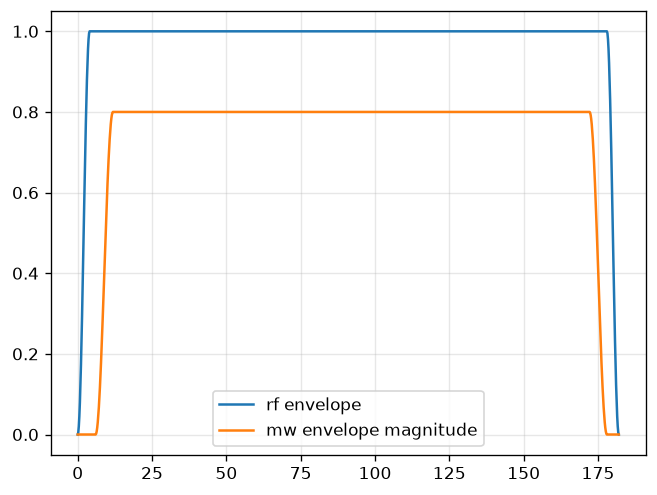

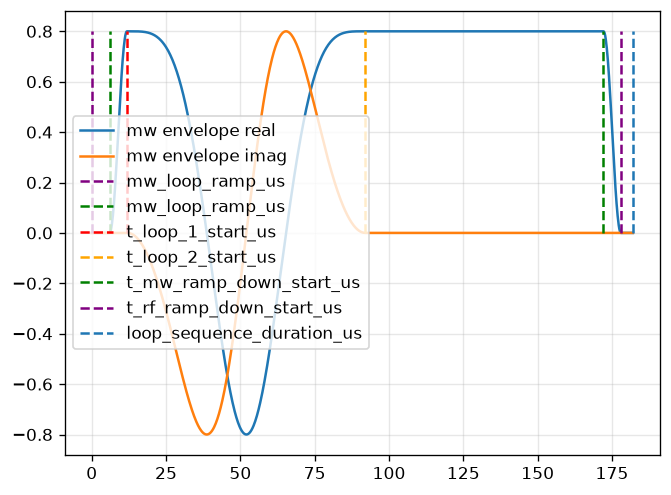

In [ ]:
def sin2_envelope(time_us, T):
    return np.sin((np.pi * time_us) / (2 * T))**2

def rf_envelope(time_us):
    ramp_start_time_us = time_us - t_rf_ramp_start_us
    ramp_end_time_us = time_us - t_rf_ramp_down_start_us
    ramp_up = np.sin((np.pi * ramp_start_time_us) / (2 * rf_loop_ramp_us)) ** 2
    ramp_down = 1.0 - np.sin((np.pi * ramp_end_time_us) / (2 * rf_loop_ramp_us)) ** 2

    envelope = np.where(
        time_us < t_rf_on_us,
        ramp_up,
        np.where(
            time_us < t_rf_ramp_down_start_us,
            1.0,
            np.where(time_us < t_rf_zero_us, ramp_down, 0.0),
        ),
    )
    return float(envelope) if envelope.ndim == 0 else envelope

def mw_berry_loop_envelope(loop_time_us):
    phi_t_us = 2 * np.pi * sin2_envelope(loop_time_us, berry_loop_duration_us)
    return np.exp(-1j * phi_t_us)

def mw_loop_sequence_envelope(time_us, loop = "C1"): # TODO : QuaCCAToo requires the envelopes to be float resolvable, URGENT FIX
    # rf plateau, MW is all zeros
    plateau_time = time_us[time_us < mw_loop_ramp_us]
    plateau = np.zeros_like(plateau_time)

    # make the time and the mw amplitude when ramping up
    ramp_up_time_bool = np.logical_and(time_us > mw_loop_ramp_us, time_us < t_loop_1_start_us)
    ramp_up_time = time_us[ramp_up_time_bool]
    zeroed_ramp_up_time = ramp_up_time - ramp_up_time[0]
    ramp_up = sin2_envelope(zeroed_ramp_up_time, np.max(zeroed_ramp_up_time))

    # perform the first loop which targets g-
    loop_1_time_bool = np.logical_and(time_us > t_loop_1_start_us, time_us < t_loop_2_start_us)
    loop_1_time = time_us[loop_1_time_bool]
    zeroed_loop_1_time = loop_1_time - loop_1_time[0]
    loop_1 = mw_berry_loop_envelope(zeroed_loop_1_time)

    # immediately fire the second loop, g- is constant for this
    loop_2_time_bool = np.logical_and(time_us > t_loop_2_start_us, time_us < t_mw_ramp_down_start_us)
    loop_2_time = time_us[loop_2_time_bool]
    zeroed_loop_2_time = loop_2_time - loop_2_time[0]
    loop_2 = np.ones_like(zeroed_loop_2_time)

    # keep constant if not state for loop
    loop_12_time = np.concatenate((loop_1_time, loop_2_time))
    const = np.ones_like(loop_12_time)

    # ramp the MWs down
    ramp_down_time_bool = np.logical_and(time_us > t_mw_ramp_down_start_us, time_us < t_rf_ramp_down_start_us)
    ramp_down_time = time_us[ramp_down_time_bool]
    zeroed_ramp_down_time = ramp_down_time - ramp_down_time[0]
    ramp_down = (1 - sin2_envelope(zeroed_ramp_down_time, np.max(zeroed_ramp_down_time)))

    # keep the MWs 0 during RF ramp down
    rf_ramp_down_time_bool = np.logical_and( time_us > t_rf_ramp_down_start_us, time_us < loop_sequence_duration_us)
    rf_ramp_down_time = time_us[rf_ramp_down_time_bool]
    zeroed_rf_ramp_down_time = rf_ramp_down_time - rf_ramp_down_time[0]
    rf_ramp_down =  np.zeros_like(zeroed_rf_ramp_down_time)

    # to preserve the length append 0 at the end
    if loop == "C1":
        mw_envelope = np.concatenate((plateau, ramp_up, loop_1, loop_2, ramp_down, rf_ramp_down, [0] ))
    elif loop == "C2":
        mw_envelope = np.concatenate((plateau, ramp_up, loop_2, loop_1, ramp_down, rf_ramp_down, [0] ))
    elif loop =="const":
        mw_envelope = np.concatenate((plateau, ramp_up, const, ramp_down, rf_ramp_down, [0] ))

    else:
        raise ValueError("Loop must be 'C1' or 'C2'")
    
    return mw_envelope

t = np.linspace(0, 182, 1000)
rf_envelope_plot = rf_envelope(t)
mw_envelope = MW_OMEGA * mw_loop_sequence_envelope(t, loop="C1")

plt.plot(t, rf_envelope_plot, label='rf envelope')
plt.plot(t, np.abs(mw_envelope), label='mw envelope magnitude')
plt.legend()
plt.show()

plt.plot(t, mw_envelope.real, label='mw envelope real')
plt.plot(t, mw_envelope.imag, label='mw envelope imag')
plt.vlines(0, 0, MW_OMEGA, linestyles='--', label='mw_loop_ramp_us', colors='purple')
plt.vlines(mw_loop_ramp_us, 0, MW_OMEGA, linestyles='--', label='mw_loop_ramp_us', colors='green')
plt.vlines(t_loop_1_start_us, 0, MW_OMEGA, linestyles='--', label='t_loop_1_start_us', colors='red')
plt.vlines(t_loop_2_start_us, 0, MW_OMEGA, linestyles='--', label='t_loop_2_start_us', colors='orange')
plt.vlines(t_mw_ramp_down_start_us, 0, MW_OMEGA, linestyles='--', label='t_mw_ramp_down_start_us', colors='green')
plt.vlines(t_rf_ramp_down_start_us, 0, MW_OMEGA, linestyles='--', label='t_rf_ramp_down_start_us', colors='purple')
plt.vlines(loop_sequence_duration_us, 0, MW_OMEGA, linestyles='--', label='loop_sequence_duration_us')
plt.legend()
plt.show()

## Define all MW envelopes

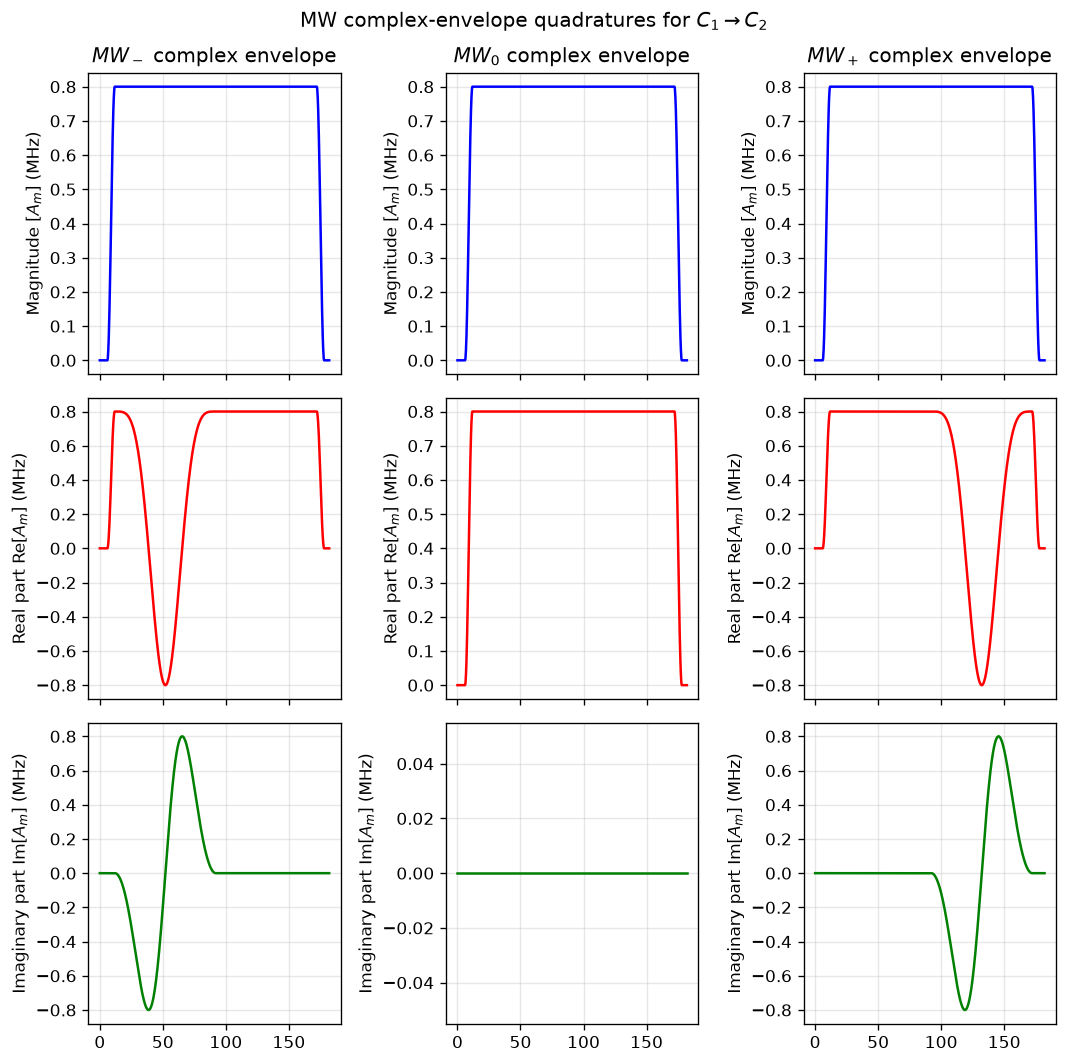

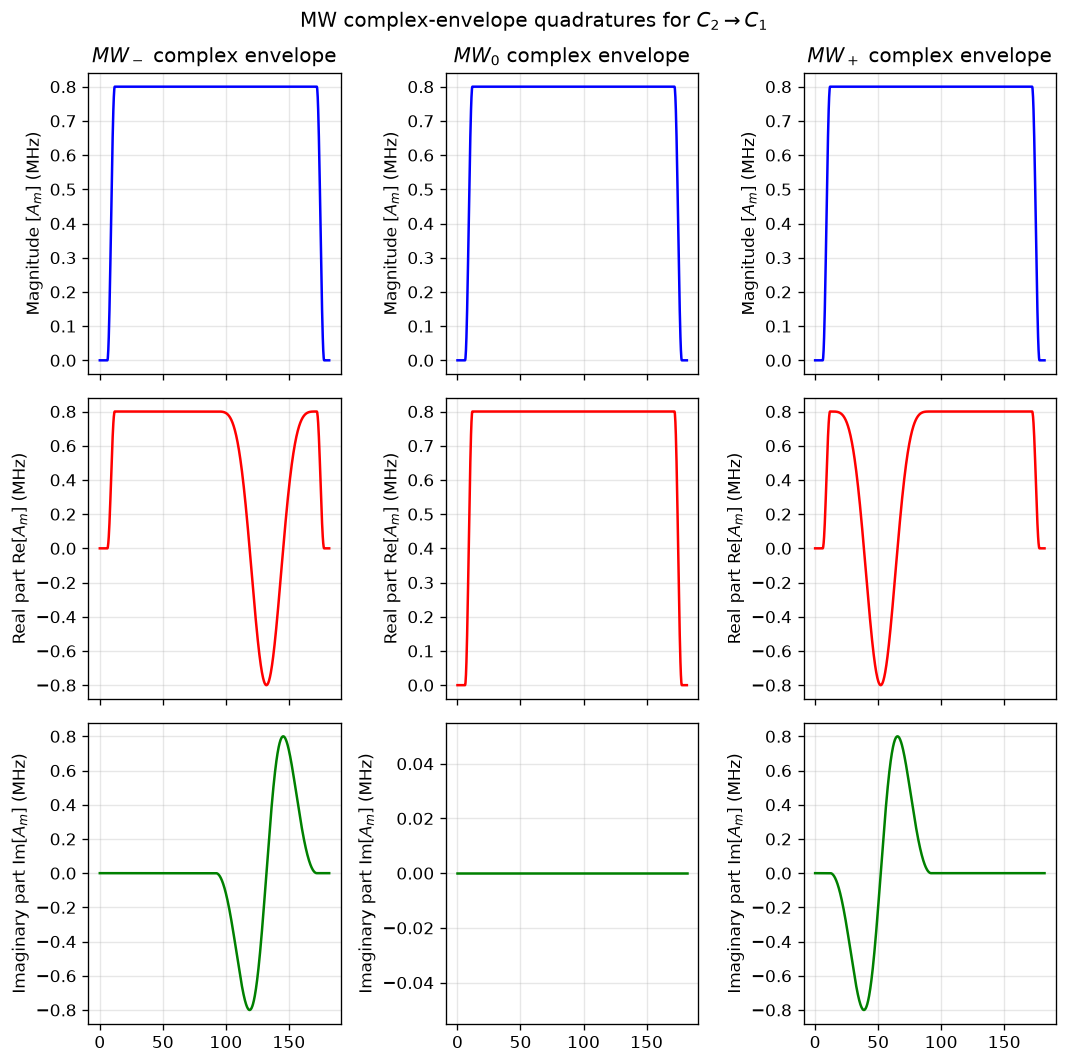

In [7]:
def mw_gminus_c1c2(time_us):
    return MW_OMEGA * mw_loop_sequence_envelope(time_us, loop="C1")

def mw_gminus_c2c1(time_us):
    return MW_OMEGA * mw_loop_sequence_envelope(time_us, loop="C2")

def mw_gplus_c1c2(time_us):
    return MW_OMEGA * mw_loop_sequence_envelope(time_us, loop="C2")

def mw_gplus_c2c1(time_us):
    return MW_OMEGA * mw_loop_sequence_envelope(time_us, loop="C1")

def mw_gzero_c1c2(time_us):
    return MW_OMEGA * mw_loop_sequence_envelope(time_us, loop="const")

def mw_gzero_c2c1(time_us):
    return MW_OMEGA * mw_loop_sequence_envelope(time_us, loop="const")


mw_gminus_c1c2_plot = mw_gminus_c1c2(SIMULATION_TIME)
mw_gminus_c2c1_plot = mw_gminus_c2c1(SIMULATION_TIME)
mw_gplus_c1c2_plot = mw_gplus_c1c2(SIMULATION_TIME)
mw_gplus_c2c1_plot = mw_gplus_c2c1(SIMULATION_TIME)
mw_gzero_c1c2_plot = mw_gzero_c1c2(SIMULATION_TIME)
mw_gzero_c2c1_plot = mw_gzero_c2c1(SIMULATION_TIME)

mw_plots = [[mw_gminus_c1c2_plot, mw_gzero_c1c2_plot, mw_gplus_c1c2_plot], [mw_gminus_c2c1_plot, mw_gzero_c2c1_plot, mw_gplus_c2c1_plot]]
suptitles = [r"MW complex-envelope quadratures for $C_1 \rightarrow C_2$", r"MW complex-envelope quadratures for $C_2 \rightarrow C_1$"]
mw_titles = [r"$MW_-$ complex envelope", r"$MW_0$ complex envelope", r"$MW_+$ complex envelope"]

for mw_loop, suptitle in zip(mw_plots, suptitles):
    fig, ax = plt.subplots(3, 3, figsize=[9, 9], sharex=True)

    for mw_ind, mw, mw_title in zip(np.arange(len(mw_loop)), mw_loop, mw_titles):
        ax[0, mw_ind].plot(SIMULATION_TIME, np.abs(mw), color='blue')
        ax[0, mw_ind].set_ylabel(r"Magnitude $[A_m]$ (MHz)")

        ax[1, mw_ind].plot(SIMULATION_TIME, mw.real, color='red')
        ax[1, mw_ind].set_ylabel(r"Real part Re$[A_m]$ (MHz)")

        ax[2, mw_ind].plot(SIMULATION_TIME, mw.imag, color='green')
        ax[2, mw_ind].set_ylabel(r"Imaginary part Im$[A_m]$ (MHz)")

        ax[0, mw_ind].set_title(mw_title)

    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


## Define all carrier functions for pulses and Static Ham with RF

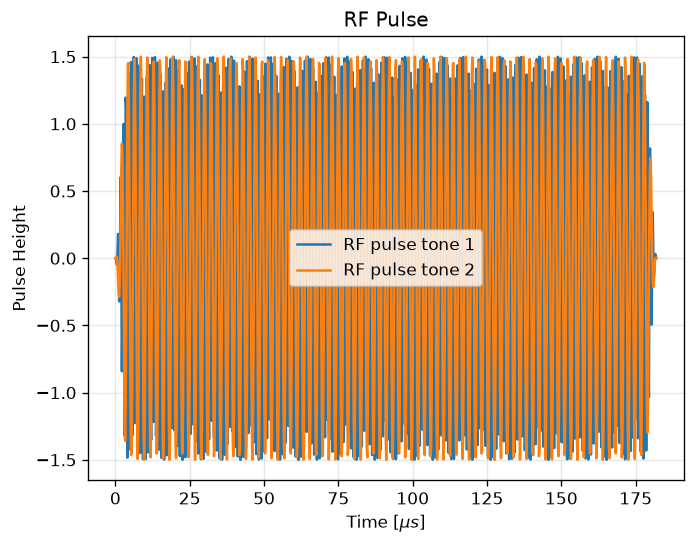

In [8]:
# for the pulses, use the envelope multiplied by a carrier cosine wave
#   A small note : the coefficients are the functions which define the shape of the pulse
#                   the pulses themselves are actually defined as the RF/MW hamiltonian * RF/MW coefficient

# first, define the rf rabi amplitudes
#   Note : we are using equal couplings for equal transition probabilities
rf_minus_zero_rabi_mhz = RF_OMEGA
rf_zero_plus_rabi_mhz = RF_OMEGA

# define a two-tone RF pulse to account for the transition frequencies between the excited states
def rf_lab_coefficient_tone_1(t, **kwargs):
    solver_time = t / (2. * np.pi)
    tone_1 = np.cos(solver_time * bare_excited_transition_frequencies_mhz[0] + RF_PHASES[0]) # e- <-> e0 transition tone

    # get the rf envelope
    envelope = rf_envelope(solver_time)
    pulse_1 = rf_minus_zero_rabi_mhz * tone_1

    return envelope * pulse_1

def rf_lab_coefficient_tone_2(t, **kwargs):
    solver_time = t / (2.0 * np.pi)
    tone_2 = np.cos(solver_time * bare_excited_transition_frequencies_mhz[1] + RF_PHASES[1]) # e0 <-> e+ transition tone

    envelope = rf_envelope(solver_time)
    pulse_2 = rf_zero_plus_rabi_mhz * tone_2

    return envelope * pulse_2

test_sim_time = SIMULATION_TIME * np.pi * 2
plt.plot(SIMULATION_TIME, rf_lab_coefficient_tone_1(test_sim_time), label='RF pulse tone 1')
plt.plot(SIMULATION_TIME, rf_lab_coefficient_tone_2(test_sim_time), label='RF pulse tone 2')
plt.legend()
plt.xlabel(r"Time $[\mu s]$")
plt.ylabel("Pulse Height")
plt.title("RF Pulse")
plt.show()

## Construct the static dressed ham in lab frame using RWA approximation

In [21]:
# project the RF hamiltonian into the bare excited basis
rf_projected_matrix = np.array([
    [final_state.dag() * nv.RF_h1 * initial_state for final_state in bare_excited_states]
    for initial_state in bare_excited_states
])
print(f'the rf matrix projected into the bare excited basis is\n{rf_projected_matrix}\n')

# we want the two matrix elements which tie e- <-> e0 and e0 <-> e+
d_minus_zero = rf_projected_matrix[1, 0] # <e- | H_RF | e0>
d_zero_plus = rf_projected_matrix[2, 1] # <e0 | H_RF | e+>
assert rf_projected_matrix[1, 0] == rf_projected_matrix[0, 1].conj() # make sure <e- | H_RF | e0> = <e0 | H_RF | e->*
assert rf_projected_matrix[2, 1] == rf_projected_matrix[1, 2].conj() # similarly for the other transition element

# apply rotating wave approximation
#   Note : check the latex after this cell
g_minus_zero = ((rf_minus_zero_rabi_mhz / 2) * 
                    d_minus_zero *
                    np.exp(-1j * RF_PHASES[0])
)
g_zero_plus = ((rf_zero_plus_rabi_mhz / 2) * 
                    d_zero_plus *
                    np.exp(-1j * RF_PHASES[1])
)

# assemble the dressed ham with detunings included
H_dressed_mhz = np.diag(DETUNINGS_MHZ).astype(np.complex128)
H_dressed_mhz[1, 0] = g_minus_zero
H_dressed_mhz[0, 1] = g_minus_zero.conj()
H_dressed_mhz[2, 1] = g_zero_plus
H_dressed_mhz[1, 2] = g_zero_plus.conj()
print(f'the dressed static hamiltonian from RWA with RF and detunings included is\n{H_dressed_mhz}\n')

# diagonalize the dressed hamiltonian
dressed_quasienergies_mhz, dressed_eigenstates = np.linalg.eigh(H_dressed_mhz)
print("Dressed quasienergies:")
print(dressed_quasienergies_mhz)
print("Dressed coefficient vectors:")
print(dressed_eigenstates)
print()

the rf matrix projected into the bare excited basis is
[[0.        +0.j 0.99999932+0.j 0.        +0.j]
 [0.99999932+0.j 0.        +0.j 1.        +0.j]
 [0.        +0.j 1.        +0.j 0.        +0.j]]

the dressed static hamiltonian from RWA with RF and detunings included is
[[0.        +0.j 0.74999949-0.j 0.        +0.j]
 [0.74999949+0.j 0.        +0.j 0.75      -0.j]
 [0.        +0.j 0.75      +0.j 0.        +0.j]]

Dressed quasienergies:
[-1.06065981e+00  8.85606963e-17  1.06065981e+00]
Dressed coefficient vectors:
[[ 4.99999830e-01+0.j -7.07107022e-01+0.j  4.99999830e-01+0.j]
 [-7.07106781e-01+0.j -2.15105711e-16+0.j  7.07106781e-01+0.j]
 [ 5.00000170e-01+0.j  7.07106541e-01+0.j  5.00000170e-01+0.j]]



RWA math:

The first RF tone is $\Omega_{-0} = \cos(2 \pi f_{-0} t+ \phi_{-0})$

We can split the cosine into two terms using $\cos(\theta) = \frac{1}{2}(e^{i \theta} + e^{-i \theta})$ and discard the positive exponential. The positive exponential is discarded because it is rotating quickly, so it can be approximated as 0.
Then we can write the rotating wave approximation and find two components:

$g_{-0} = \frac{\Omega_{-0}}{2} d_{-0} e^{-i \phi_{-0}}$ $g_{0+} = \frac{\Omega_{0+}}{2} d_{0+} e^{-i \phi_{0+}}$

Where $d_{-0}$ and $d_{0+}$ are the projected RF matrix components


## find the ancilla state in the NV basis

In [28]:
# take the lowest dressed eigenstate as the ancilla state and transform each dressed excited state
#  back into the original 9D basis. Make sure that the largest coefficient of the ancilla state is positive by 
#   by applying a global phase
dressed_excited_states = [Qobj(np.sum(dressed_coeff * np.array(bare_excited_states))) for dressed_coeff in dressed_eigenstates.T]
ancilla_state, dressed_e_zero, dressed_e_plus = dressed_excited_states
ancilla_nine_coefficients = [coeff[0] for coeff in ancilla_state]
max_ancilla_coeff_ind = np.argmax(np.abs(ancilla_nine_coefficients))
global_phase = ancilla_nine_coefficients[max_ancilla_coeff_ind] / np.abs(ancilla_nine_coefficients[max_ancilla_coeff_ind])
ancilla_state = global_phase * ancilla_state
print(f'the ancilla state is\n{ancilla_state}')

# get the ancilla quasienergy
ancilla_quasienergy_mhz = dressed_quasienergies_mhz[0]
print(f'the ancilla quasienergy is : {ancilla_quasienergy_mhz} [MHz]\n')

# test the projection operators between the bare and dressed excited states
bare_projectors = [ket2dm(state) for state in bare_excited_states]

dressed_projectors = [ket2dm(state) for state in dressed_excited_states]
assert (
    np.sum(dressed_projectors) - np.sum(bare_projectors)
).norm() < 1e-12

# test orthonormality of the states
print(f'<e|e> = {ancilla_state.dag() * ancilla_state}')
print(f'<e0|e0> = {dressed_e_zero.dag() * dressed_e_zero}')
print(f'<e+|e+> = {dressed_e_plus.dag() * dressed_e_plus}')
print(f'<e|e+> = {ancilla_state.dag() * dressed_e_plus}')
print(f'<e+|e0> = {dressed_e_plus.dag() * dressed_e_zero}')
print(f'<e|e0> = {ancilla_state.dag() * dressed_e_zero}')


the ancilla state is
Quantum object: dims=[[3, 3], [1]], shape=(9, 1), type='ket', dtype=Dense
Qobj data =
[[-0.00000000e+00]
 [-0.00000000e+00]
 [ 1.40954101e-06]
 [-0.00000000e+00]
 [ 5.85282134e-04]
 [-8.24897872e-04]
 [-4.99999828e-01]
 [ 7.07106300e-01]
 [-4.99999830e-01]]
the ancilla quasienergy is : -1.060659810906894 [MHz]

<e|e> = (1+0j)
<e0|e0> = (0.9999999999999998+0j)
<e+|e+> = (0.9999999999999998+0j)
<e|e+> = (8.326672684688674e-17+0j)
<e+|e0> = (5.551115123125783e-17+0j)
<e|e0> = (-2.7755575615628914e-16+0j)


## put the MW transition frequencies in tune with the new ancilla state

Currently we have the transitions of each ground state to its corresponding undressed excited states via a $\Delta m_s = \pm 1$ transition.
However, because we have now dressed the excited states, our energies have shifted and therefore we msut correct the MW pulse frequencies.

In [ ]:
mw_transition_matrix # TODO : what are the rows/columns and why is there a small ms=2 channel?

array([[ 9.99999320e-01+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  9.99997405e-01+0.j,  0.00000000e+00+0.j],
       [-4.18463760e-06+0.j,  0.00000000e+00+0.j,  9.99998086e-01+0.j]])

In [33]:
# TODO : this is incorrect, determine whether we get the effective Omega (E_ancilla - E_gm) 
    # or get the full Omegas (E_em - E_gm)
ancilla_mw_frequencies_mhz = bare_mw_frequencies_mhz + ancilla_quasienergy_mhz
labels = ["MW-", "MW0", "MW+"]
print(f'the shifted MW frequencies to the dressed ancilla state are\n')
for lab, freq, freq_bare in zip(labels, ancilla_mw_frequencies_mhz, bare_mw_frequencies_mhz):
    print(f'{lab} shifted: {freq} [MHz]')
    print(f'{lab} bare: {freq_bare} [MHz]\n')

def mw_minus_pulse_C1C2(t, **kwargs):
    freq = ancilla_mw_frequencies_mhz[0]
    solver_time = t / (2 * np.pi)
    carrier = np.cos(solver_time * freq + MW_PHASES[0])
    envelope = mw_loop_sequence_envelope(solver_time, loop="C1")
    return carrier * envelope

def mw_zero_pulse_C1C2(t, **kwargs):
    freq = ancilla_mw_frequencies_mhz[1]
    solver_time = t / (2 * np.pi)
    carrier = np.cos(solver_time * freq + MW_PHASES[1])
    envelope = mw_loop_sequence_envelope(solver_time, loop="C1")
    return carrier * envelope

def mw_plus_pulse_C1C2(t, **kwargs):
    freq = ancilla_mw_frequencies_mhz[2]
    solver_time = t / (2 * np.pi)
    carrier = np.cos(solver_time * freq + MW_PHASES[2])
    envelope = mw_loop_sequence_envelope(solver_time, loop="C1")
    return carrier * envelope

def mw_minus_pulse_C2C1(t, **kwargs):
    freq = ancilla_mw_frequencies_mhz[0]
    solver_time = t / (2 * np.pi)
    carrier = np.cos(solver_time * freq + MW_PHASES[0])
    envelope = mw_loop_sequence_envelope(solver_time, loop="C2")
    return carrier * envelope

def mw_zero_pulse_C2C1(t, **kwargs):
    freq = ancilla_mw_frequencies_mhz[1]
    solver_time = t / (2 * np.pi)
    carrier = np.cos(solver_time * freq + MW_PHASES[1])
    envelope = mw_loop_sequence_envelope(solver_time, loop="C2")
    return carrier * envelope

def mw_plus_pulse_C2C1(t, **kwargs):
    freq = ancilla_mw_frequencies_mhz[2]
    solver_time = t / (2 * np.pi)
    carrier = np.cos(solver_time * freq + MW_PHASES[2])
    envelope = mw_loop_sequence_envelope(solver_time, loop="C2")
    return carrier * envelope

the shifted MW frequencies to the dressed ancilla state are

MW- shifted: 2306.3034622399837 [MHz]
MW- bare: 2307.3641220508907 [MHz]

MW0 shifted: 2308.4487495637222 [MHz]
MW0 bare: 2309.5094093746293 [MHz]

MW+ shifted: 2310.585594908677 [MHz]
MW+ bare: 2311.6462547195842 [MHz]



In [29]:
H_dressed_mhz

array([[0.        +0.j, 0.74999949-0.j, 0.        +0.j],
       [0.74999949+0.j, 0.        +0.j, 0.75      -0.j],
       [0.        +0.j, 0.75      +0.j, 0.        +0.j]])

## construct the observable projection operators

In [12]:
P_g_minus = ket2dm(g_minus)
P_g_zero = ket2dm(g_zero)
P_g_plus = ket2dm(g_plus)

P_ancilla = ket2dm(ancilla_state)
P_e_zero = ket2dm(dressed_excited_states[1])
P_e_plus = ket2dm(dressed_excited_states[2])

P_s_minus = ket2dm(s_minus)
P_s_zero = ket2dm(s_zero)
P_s_plus = ket2dm(s_plus)

P_tripod_states = P_g_minus + P_g_zero + P_g_plus + P_ancilla # the population of all tripod states
P_all_ground_and_excited_states = P_tripod_states + P_e_zero + P_e_plus
P_all_states = P_all_ground_and_excited_states + P_s_minus + P_s_zero + P_s_plus

## Do the pulsed sim experiments in the loops

In [13]:
loop_population_observables = [
    P_g_minus,
    P_g_zero,
    P_g_plus,
    P_ancilla,
    P_tripod_states,
    P_all_ground_and_excited_states,
    P_all_states,
]
loop_population_labels = (
    r"$P_{g_-}$",
    r"$P_{g_0}$",
    r"$P_{g_+}$",
    r"$P_{\text{ancilla}}$",
    r"$P_{\text{tripod}}$",
    r"$P_{G+E}$",
    r"$P_{\rm all}$",
)

initial_state = g_minus # initial state for the system
solver_total_simulation_time = SIMULATION_TIME * (2 * np.pi)

system = QSys(
    H0 = nv.H0.copy(), # should it be this or H_dressed_mhz ... I think this
    rho0 = initial_state,
    observable=None,
    units_H0="MHz"
)

# define the RF and MW hamiltonians, these are the given NV RF/MW hamiltonians 
#   scaled by their respective Rabi frequencies
RF_hamiltonians = [RF_OMEGA * nv.RF_h1, RF_OMEGA * nv.RF_h1]
MW_hamiltonians = [MW_OMEGA * nv.MW_h1, MW_OMEGA * nv.MW_h1, MW_OMEGA * nv.MW_h1]
control_hamiltonians = RF_hamiltonians + MW_hamiltonians

# define the pulse shapes of the RF and MW pulses, these are the envelopes of each pulse
#   multiplied by a cosine term with the correct transition frequency
RF_pulse_shapes = [rf_lab_coefficient_tone_1, rf_lab_coefficient_tone_2]
MW_pulse_shapes = [mw_minus_pulse_C1C2, mw_zero_pulse_C1C2, mw_plus_pulse_C1C2]
pulse_shapes = RF_pulse_shapes + MW_pulse_shapes

# define the experiment and add the pulses
experiment = PulsedSim(system = system)

# add the two tone RF pulse and MW pulses all at the same time
experiment.add_pulse(
    duration=loop_sequence_duration_us,
    h1=control_hamiltonians,
    pulse_shape=pulse_shapes,
    time_steps=int(np.ceil(loop_sequence_duration_us / 0.5)) + 1,
    options={"nsteps": 500_000, "atol": 1e-10, "rtol": 1e-9}
)

TypeError: 'float' object is not subscriptable